In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('/content/E-commerce Website Logs.csv')

/tmp/ipykernel_153/4156447900.py:6: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/E-commerce Website Logs.csv')


In [ ]:
df

,accessed_date,duration_(secs),network_protocol,ip,bytes,accessed_Ffom,age,gender,country,membership,language,sales,returned,returned_amount,pay_method
0,2017-03-14 17:43:57.172,2533,TCP,1.10.195.126,20100,Chrome,28,Female,CA,Normal,English,261.9600,No,0.00,Credit Card
1,2017-03-14 17:43:57.172,4034,TCP,1.1.217.211,20500,Mozilla Firefox,21,Male,AR,Normal,English,731.9400,No,0.00,Debit Card
2,2017-03-14 17:43:26.135,1525,TCP,1.115.198.107,90100,Mozilla Firefox,20,Male,PL,Normal,English,14.6200,No,0.00,Cash
3,2017-03-14 17:43:26.135,4572,TCP,1.121.152.143,100300,Mozilla Firefox,66,Female,IN,Normal,Spanish,957.5775,No,0.00,Credit Card
4,2017-03-14 18:17:09.005,3652,TCP,1.123.135.213,270200,Mozilla Firefox,53,Female,KR,Normal,Spanish,22.3680,No,0.00,Cash
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172833,2017-03-16 11:42:01.298,4372,TCP,94.197.121.229,100600,Android App,NaN,Male,US,Normal,English,0.0000,Yes,143.36,Debit Card
172834,2017-03-16 12:10:17.340,2167,TCP,129.110.241.72,30400,Android App,NaN,Female,IT,Normal,English,15.1500,No,0.00,Cash
172835,2017-03-16 12:10:17.340,2725,TCP,185.119.252.121,100300,Android App,NaN,Female,IT,Normal,English,600.1600,No,0.00,Credit Card
172836,2017-03-16 15:52:58.342,3728,TCP,185.145.107.23,50200,Android App,NaN,Male,US,Normal,Russian,75.7500,No,0.00,Cash


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 172838 entries, 0 to 172837
Data columns (total 15 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   accessed_date     172838 non-null  object 
 1   duration_(secs)   172838 non-null  int64  
 2   network_protocol  172838 non-null  object 
 3   ip                172838 non-null  object 
 4   bytes             172838 non-null  int64  
 5   accessed_Ffom     172838 non-null  object 
 6   age               99457 non-null   object 
 7   gender            172838 non-null  object 
 8   country           172838 non-null  object 
 9   membership        172838 non-null  object 
 10  language          172838 non-null  object 
 11  sales             172838 non-null  float64
 12  returned          172838 non-null  object 
 13  returned_amount   172838 non-null  float64
 14  pay_method        172838 non-null  object 
dtypes: float64(2), int64(2), object(11)
memory usage: 19.8+ MB


In [ ]:
# Ordenando pela data
df = df.sort_values('accessed_date')

In [ ]:
df['pay_method'].value_counts()

,count
pay_method,
Cash,72670
Credit Card,53031
Debit Card,27497
Others,19640


In [ ]:
df['network_protocol'].value_counts()

,count
network_protocol,
TCP,127825
HTTP,34874
ICMP,7869
UDP,2233
HTTP,37


In [ ]:
df['network_protocol'].unique()

array(['TCP  ', 'ICMP ', 'HTTP', 'UDP  ', 'HTTP  '], dtype=object)

In [ ]:
# Corrigindo o erro encontrado na coluna de protocolo
df['network_protocol'] = df['network_protocol'].str.strip()

In [ ]:
df['network_protocol'].unique()

array(['TCP', 'ICMP', 'HTTP', 'UDP'], dtype=object)

In [ ]:
df['accessed_Ffom'].value_counts()

,count
accessed_Ffom,
Android App,38216
Chrome,28254
Mozilla Firefox,26592
Others,26592
IOS App,21606
Safari,16467
Microsoft Edge,14958
SafFRi,153


In [ ]:
df['gender'].value_counts()

,count
gender,
Female,93903
Male,63049
Unknown,15886


In [ ]:
df['membership'].value_counts()

,count
membership,
Premium,107345
Normal,49607
Not Logged In,15886


In [ ]:
df['returned'].value_counts()

,count
returned,
No,150274
Yes,22564


In [ ]:
df['language'].value_counts()

,count
language,
English,117437
Spanish,12339
Russian,12008
Chinese,11112
French,6492
Italian,4425
German,2366
Japanese,1358
Thai,825


In [ ]:
df['country'].value_counts()

,count
country,
IT,34438
US,30408
CA,17756
CN,10177
JP,9962
RU,9532
CH,8237
IN,8011
PL,6710


In [ ]:
df['age'].value_counts()

,count
age,
--,14743
37,1771
22,1747
43,1712
51,1708
64,1707
24,1700
30,1698
40,1691


In [ ]:
# Transformando a coluna de idade como um numérico, e deixando tudo que não for um número como null
df['age'] = pd.to_numeric(df['age'], errors='coerce')

In [ ]:
df['age'].value_counts()

,count
age,
37.0,1771
22.0,1747
43.0,1712
51.0,1708
64.0,1707
24.0,1700
30.0,1698
40.0,1691
48.0,1682


In [ ]:
# Percebe-se que só possue valor nulo na idade
df.isnull().sum()

,0
accessed_date,0
duration_(secs),0
network_protocol,0
ip,0
bytes,0
accessed_Ffom,0
age,88124
gender,0
country,0
membership,0


In [ ]:
df.shape

(172838, 15)

In [ ]:
df['age'].mean()

np.float64(43.438262860920275)

In [ ]:
df['age'].median()

43.0

In [ ]:
# Aqui percebemos que todos os gêneros desconhecidos foi porque o usuário não logou
df[(df['gender'] == 'Unknown') & (df['membership'] != 'Not Logged In')]

,accessed_date,duration_(secs),network_protocol,ip,bytes,accessed_Ffom,age,gender,country,membership,language,sales,returned,returned_amount,pay_method


In [ ]:
# Vimos também que não sabemos a idade de quem não logou
df[(df['gender'] == 'Unknown') & (df['age'].notnull())]

,accessed_date,duration_(secs),network_protocol,ip,bytes,accessed_Ffom,age,gender,country,membership,language,sales,returned,returned_amount,pay_method


In [ ]:
# Decidimos manter a idade quando o usuário não fez cadastro como 0, já que não conseguimos saber a idade
df['age'] = np.where((df['gender'] == 'Unknown'), 0, df['age'])

In [ ]:
# Trocamos o método de pagamento para desconhecido porque quando a pessoa entra sem
# login ela não pode comprar, apenas depois de logar
df['pay_method'] = np.where((df['gender'] == 'Unknown'), 'Unknown', df['pay_method'])

In [ ]:
df[df['gender'] == 'Unknown']

,accessed_date,duration_(secs),network_protocol,ip,bytes,accessed_Ffom,age,gender,country,membership,language,sales,returned,returned_amount,pay_method
251,2017-03-15 00:06:40.209,2819,HTTP,2.137.104.119,21160,Others,0.0,Unknown,CH,Not Logged In,Spanish,0.0,No,0.0,Unknown
1783,2017-03-15 00:17:28.380,2891,HTTP,36.84.84.235,264,Chrome,0.0,Unknown,CA,Not Logged In,Chinese,0.0,No,0.0,Unknown
1782,2017-03-15 00:17:28.380,3682,HTTP,36.84.70.174,46,Chrome,0.0,Unknown,US,Not Logged In,Chinese,0.0,No,0.0,Unknown
1555,2017-03-15 01:07:43.366,1739,HTTP,27.97.65.43,383,Android App,0.0,Unknown,SE,Not Logged In,Chinese,0.0,No,0.0,Unknown
2649,2017-03-15 02:02:33.807,1597,HTTP,45.61.46.146,819,Safari,0.0,Unknown,CN,Not Logged In,Chinese,0.0,No,0.0,Unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172503,2017-03-21 23:35:38.096,2596,TCP,123.193.174.244,92,Others,0.0,Unknown,US,Not Logged In,English,0.0,No,0.0,Unknown
172506,2017-03-21 23:35:39.296,4865,TCP,123.201.179.246,11967,Others,0.0,Unknown,GB,Not Logged In,English,0.0,No,0.0,Unknown
172505,2017-03-21 23:35:39.296,4404,TCP,123.198.33.76,672,Others,0.0,Unknown,GB,Not Logged In,English,0.0,No,0.0,Unknown
172673,2017-03-21 23:50:37.440,2496,TCP,125.202.113.81,46,Safari,0.0,Unknown,CA,Not Logged In,English,0.0,No,0.0,Unknown


In [ ]:
df[df['accessed_date'] >= '2017-03-19 02:58:00']

,accessed_date,duration_(secs),network_protocol,ip,bytes,accessed_Ffom,age,gender,country,membership,language,sales,returned,returned_amount,pay_method
99461,2017-03-19 02:58:16.534,3366,TCP,221.193.196.156,46,Others,NaN,Female,IN,Premium,English,26.15,No,0.000,Cash
99462,2017-03-19 02:58:16.534,3988,TCP,221.195.29.62,40,Others,NaN,Female,IT,Premium,English,2400.68,No,0.000,Credit Card
99500,2017-03-19 02:58:17.192,3527,TCP,222.255.236.117,1285,Mozilla Firefox,NaN,Female,RU,Premium,English,0.00,Yes,130.112,Others
99499,2017-03-19 02:58:17.192,4536,TCP,222.255.236.117,424,Others,NaN,Female,CA,Premium,English,1500.40,No,0.000,Cash
99475,2017-03-19 02:58:34.137,4179,TCP,222.152.159.155,419,IOS App,NaN,Female,US,Premium,English,26.15,No,0.000,Credit Card
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172811,2017-03-21 23:58:40.558,3416,TCP,128.72.46.60,515,Chrome,NaN,Female,CO,Normal,Russian,162.64,No,0.000,Cash
172814,2017-03-21 23:59:17.705,1609,TCP,128.75.100.147,2231,Others,NaN,Female,CA,Premium,Thai,0.00,Yes,143.360,Others
172815,2017-03-21 23:59:17.705,3301,TCP,128.75.118.137,3081,Others,NaN,Female,RU,Premium,English,15.15,No,0.000,Debit Card
172816,2017-03-21 23:59:30.671,4188,TCP,128.75.85.12,2531,Others,NaN,Female,AT,Premium,English,600.16,No,0.000,Cash


In [ ]:
# Por algum motivo, depois das 2:58:00 do dia 19 não se teve a idade de mais nenhum cliente,
# mesmo os que logaram
df[(df['accessed_date'] >= '2017-03-19 02:58:00') & (df['age'].notnull()) & (df['age'] != 0)]

,accessed_date,duration_(secs),network_protocol,ip,bytes,accessed_Ffom,age,gender,country,membership,language,sales,returned,returned_amount,pay_method


In [ ]:
# Como sbustituimos os nulos da idade de quem não fez o cadastro por 0, alteramos a mediana,
# por isso substituimos os nulos pela mediana antiga
df['age'] = df['age'].fillna(43)

In [ ]:
df.columns

Index(['accessed_date', 'duration_(secs)', 'network_protocol', 'ip', 'bytes',
       'accessed_Ffom', 'age', 'gender', 'country', 'membership', 'language',
       'sales', 'returned', 'returned_amount', 'pay_method'],
      dtype='object')

In [ ]:
df.pay_method.unique()

array(['Cash', 'Credit Card', 'Debit Card', 'Others', 'Unknown'],
      dtype=object)

In [ ]:
# Forma de pagamento mais utilizada para cada país
df.groupby("country")["pay_method"].agg(lambda x: x.value_counts().idxmax())

,pay_method
country,
AE,Cash
AR,Cash
AT,Cash
AU,Cash
CA,Cash
CH,Cash
CN,Cash
CO,Cash
DE,Cash


In [ ]:
df["hour"] = pd.to_datetime(df["accessed_date"]).dt.hour

In [ ]:
df["returned"].unique()

array(['No', 'Yes'], dtype=object)

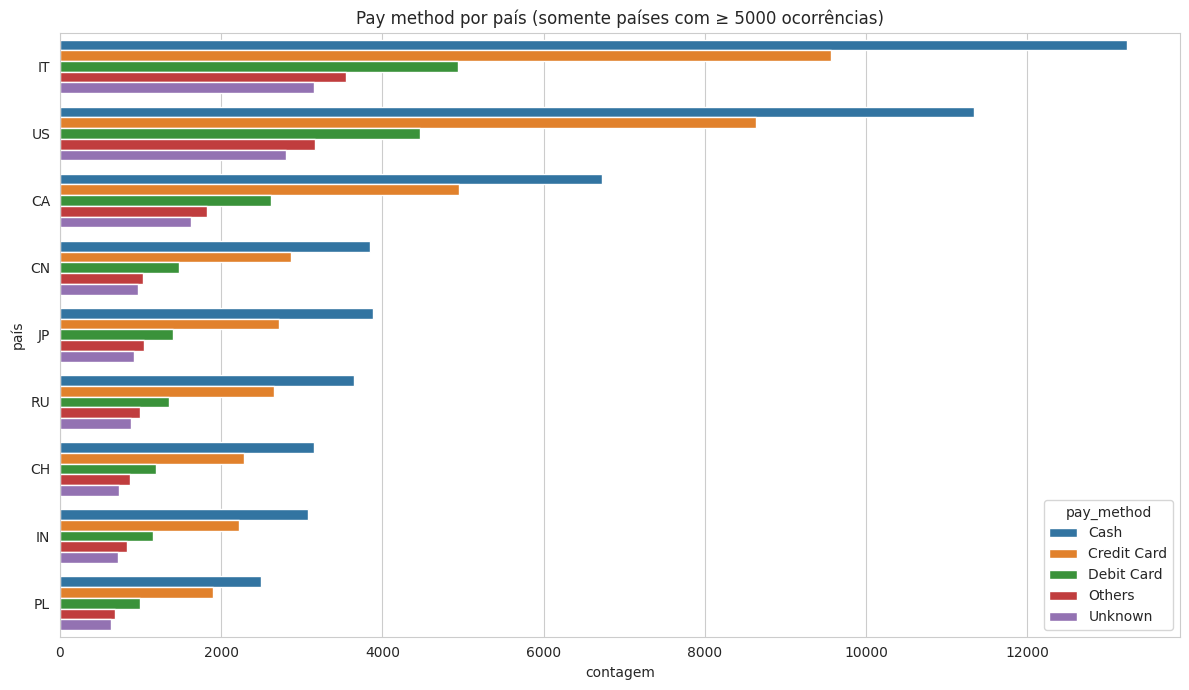

In [ ]:
def plot_n_paises(n):
  df_f=df[df["country"].map(df["country"].value_counts())>=n]
  order=df_f["country"].value_counts().index

  plt.figure(figsize=(12,7))
  sns.countplot(data=df_f, y="country", hue="pay_method", order=order)
  plt.title(f"Pay method por país (somente países com ≥ {n} ocorrências)")
  plt.xlabel("contagem")
  plt.ylabel("país")
  plt.tight_layout()
  plt.show()
plot_n_paises(5000)

In [ ]:
print(df['membership'].unique())

['Normal' 'Premium' 'Not Logged In']


In [ ]:
# Excluir quem não logou
df_log = df[df["membership"].ne("Not Logged In")].copy()

# Mapear Normal -> 0, Premium -> 1
df_log["membership"] = (
    df_log["membership"].astype(str).str.strip().str.lower()
      .map({"normal": 0, "premium": 1})
)

df_log["membership"].value_counts(dropna=False)

,count
membership,
1,107345
0,49607


In [ ]:
print(df_log["membership"].unique())

[0 1]


In [ ]:
df_log["age_group"] = pd.cut(
    df_log["age"],
    bins=[0,18,25,35,45,55,65,100],
    labels=["0-18","18-25","25-35","35-45","45-55","55-65","65+"]
)

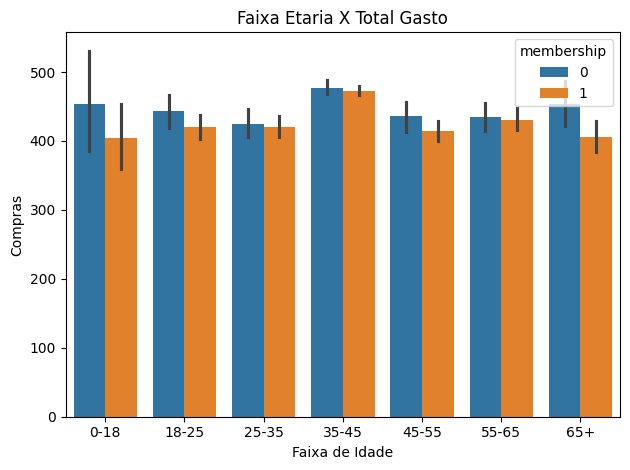

In [ ]:
sns.barplot(data=df_log, x="age_group", y="sales", hue="membership")
plt.title(f"Faixa Etaria X Total Gasto")
plt.xlabel("Faixa de Idade")
plt.ylabel("Compras")
plt.tight_layout()
plt.show()

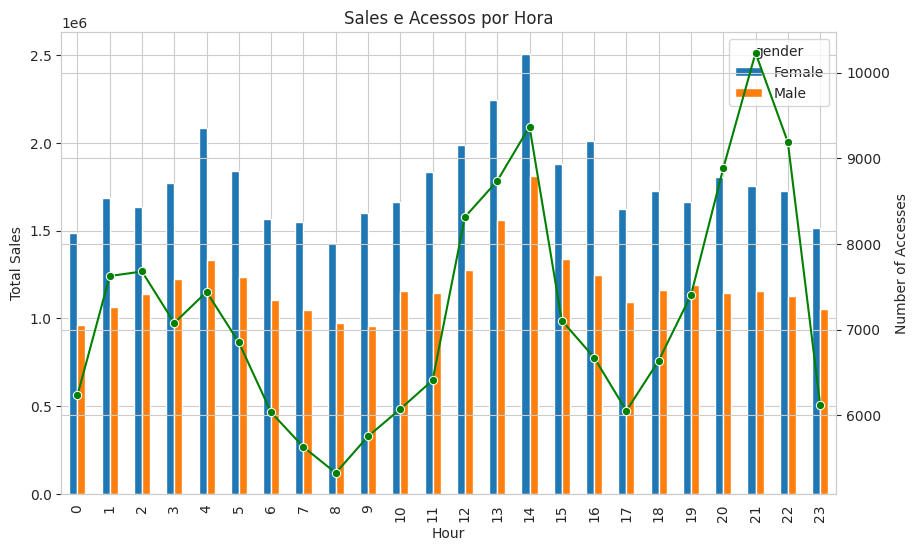

In [ ]:
sales_group = df_log.groupby(['hour','gender'])['sales'].sum().unstack()

access_per_hour = df['hour'].value_counts().sort_index()

fig, ax1 = plt.subplots(figsize=(10,6))

sales_group.plot(kind='bar', ax=ax1)
ax1.set_xlabel("Hour")
ax1.set_ylabel("Total Sales")

ax2 = ax1.twinx()

sns.lineplot(
    x=access_per_hour.index,
    y=access_per_hour.values,
    marker="o",
    color="green",
    ax=ax2
)

ax2.set_ylabel("Number of Accesses")

plt.title("Sales e Acessos por Hora")
plt.show()

In [ ]:
df_log["sales"].describe()

,sales
count,156952.000000
mean,452.981150
std,812.814497
min,0.000000
25%,15.150000
50%,75.750000
75%,600.160000
max,11199.968000


In [ ]:
# Substituindo os valores de "returned" por 0 e 1

df_log["returned"] = (df_log["returned"].map({"No": 0, "Yes": 1}))

In [ ]:
df_num=df_log.select_dtypes(include=[np.number])
df_num

,duration_(secs),bytes,age,membership,sales,returned,returned_amount,hour
2,1525,90100,20.0,0,14.6200,0,0.00,17
3,4572,100300,66.0,0,957.5775,0,0.00,17
15,4716,50800,24.0,0,2.5440,0,0.00,17
14,2440,330000,67.0,0,68.8100,0,0.00,17
0,2533,20100,28.0,0,261.9600,0,0.00,17
...,...,...,...,...,...,...,...,...
172811,3416,515,43.0,0,162.6400,0,0.00,23
172814,1609,2231,43.0,1,0.0000,1,143.36,23
172815,3301,3081,43.0,1,15.1500,0,0.00,23
172816,4188,2531,43.0,1,600.1600,0,0.00,23


In [ ]:
correlation_matrix = df_num.corr()
correlation_matrix

,duration_(secs),bytes,age,membership,sales,returned,returned_amount,hour
duration_(secs),1.000000,0.004843,0.000679,-0.000911,-0.001425,0.001512,0.000786,-0.002072
bytes,0.004843,1.000000,0.000581,0.078021,-0.000747,-0.002556,-0.000519,-0.005066
age,0.000679,0.000581,1.000000,-0.002482,0.001085,-0.001022,-0.002576,-0.005101
membership,-0.000911,0.078021,-0.002482,1.000000,-0.003774,-0.004621,-0.002535,-0.013362
sales,-0.001425,-0.000747,0.001085,-0.003774,1.000000,-0.228359,-0.119016,0.023310
returned,0.001512,-0.002556,-0.001022,-0.004621,-0.228359,1.000000,0.521179,-0.014836
returned_amount,0.000786,-0.000519,-0.002576,-0.002535,-0.119016,0.521179,1.000000,0.003009
hour,-0.002072,-0.005066,-0.005101,-0.013362,0.023310,-0.014836,0.003009,1.000000


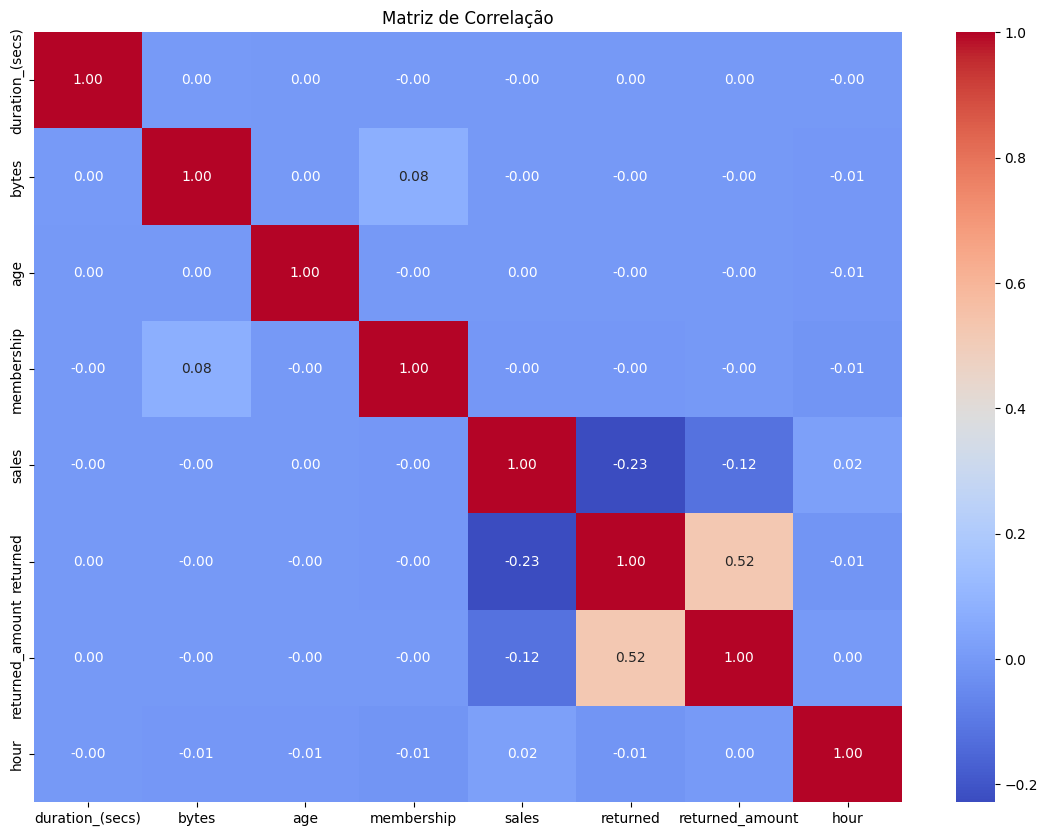

In [ ]:
plt.figure(figsize=(14, 10))

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")

plt.title('Matriz de Correlação')
plt.show()

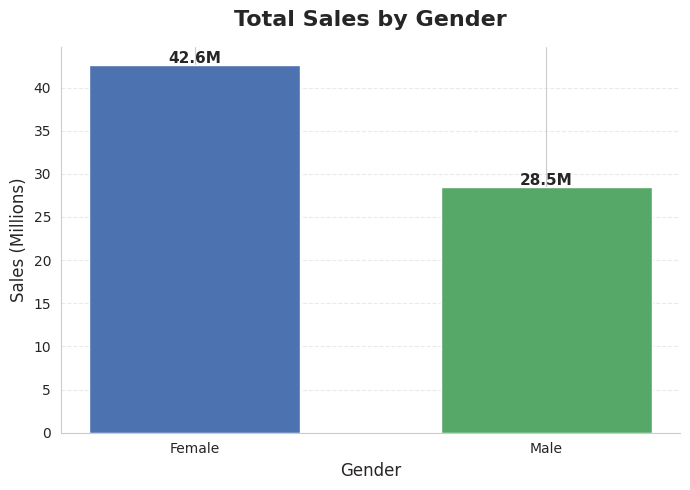

In [ ]:
sales_gender = df_log.groupby('gender')['sales'].sum() / 1e6

sns.set_style("whitegrid")

fig, ax = plt.subplots(figsize=(7,5))

colors = ["#4C72B0", "#55A868"]

bars = ax.bar(sales_gender.index, sales_gender.values, color=colors, width=0.6)

ax.set_title("Total Sales by Gender", fontsize=16, weight="bold", pad=15)
ax.set_ylabel("Sales (Millions)", fontsize=12)
ax.set_xlabel("Gender", fontsize=12)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(axis='y', linestyle='--', alpha=0.4)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.2,
        f"{height:.1f}M",
        ha='center',
        fontsize=11,
        weight='bold'
    )

plt.tight_layout()
plt.show()

In [ ]:
pct_female = sales_gender['Female'] / sales_gender.sum()

In [ ]:
# Porentagem que as mulheres compram em relação ao total

pct_female

np.float64(0.5990353080219927)